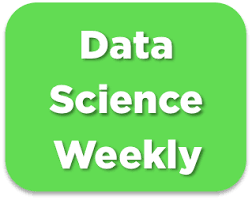

# Challenge : predict conversions 🏆🏆

This is the template that shows the different steps of the challenge. In this notebook, all the training/predictions steps are implemented for a very basic model (logistic regression with only one variable). Please use this template and feel free to change the preprocessing/training steps to get the model with the best f1-score ! May the force be with you 🧨🧨  

**For a detailed description of this project, please refer to *02-Conversion_rate_challenge.ipynb*.**

# Import libraries

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from IPython.display import display

# Read file with labels

In [14]:
df = pd.read_csv("df.csv")

# Preprocessing

## preprocessing pandas

Detect outlyers age and total_pages_visited. We apply 3 sigma rule : to 1 sigma from mean, 60% of dataset is included in area. To 2 sigma, 95% and to 3 sigma, 99%. Then we drop entries outside 3 sigma from the mean.

In [15]:
string = ['country', 'source']

for col in string:
    df[col] = df[col].str.lower()

### drop outlyers

In [16]:
upper_bound = 80
mask = df['age'] < upper_bound
mask

0         True
1         True
2         True
3         True
4         True
          ... 
284575    True
284576    True
284577    True
284578    True
284579    True
Name: age, Length: 284580, dtype: bool

In [17]:
df = df.loc[mask, :]
print("Done. Number of lines remaining : ", df.shape[0])
print(df.head())

Done. Number of lines remaining :  284578
   country  age  new_user  source  total_pages_visited  converted
0    china   22         1  direct                    2          0
1       uk   21         1     ads                    3          0
2  germany   20         0     seo                   14          1
3       us   23         1     seo                    3          0
4       us   28         1  direct                    3          0


In [18]:
df.describe(include='all')

,country,age,new_user,source,total_pages_visited,converted
count,284578,284578.000000,284578.000000,284578,284578.000000,284578.000000
unique,4,NaN,NaN,3,NaN,NaN
top,us,NaN,NaN,seo,NaN,NaN
freq,160124,NaN,NaN,139476,NaN,NaN
mean,NaN,30.563596,0.685457,NaN,4.873198,0.032251
std,NaN,8.263627,0.464334,NaN,3.341939,0.176667
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000


## preprocessing en sklearn

### Univariate logistic regression

#### divide dataset Train set & Test set 

In [19]:
# Separate target variable Y from features X
print("Separating labels from features...")
features_list = ["total_pages_visited"]
target = "converted"

X = df.loc[:, features_list]
y = df.loc[:, target]

print("...Done.")
print()

print("Y : ")
print(y.head())
print()
print("X :")
print(X.head())

Separating labels from features...
...Done.

Y : 
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

X :
   total_pages_visited
0                    2
1                    3
2                   14
3                    3
4                    3


In [20]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("...Done.")
print()


Dividing into train and test sets...
...Done.



#### pipelines

In [21]:
print("Preprocessing X_train...")
print(X_train.head())
print()
preprocessor = StandardScaler()
X_train = preprocessor.fit_transform(X_train)
print("...Done!")
print(X_train[0:5, :])  # X_train is now a numpy array
print()

print("...Done")
print(y_train[0:5])

Preprocessing X_train...
        total_pages_visited
224352                    6
202720                    4
36793                     3
211646                    4
65071                     7

...Done!
[[ 0.33808645]
 [-0.26114698]
 [-0.5607637 ]
 [-0.26114698]
 [ 0.63770316]]

...Done
224352    0
202720    0
36793     0
211646    0
65071     0
Name: converted, dtype: int64


#### Test pipeline

In [22]:
# Test pipeline
print("Preprocessing X_test...")
print(X_test.head())
print()
X_test = preprocessor.transform(X_test)
print("...Done!")
print(X_test[0:5, :])  # X_test is now a numpy array
print()


Preprocessing X_test...
        total_pages_visited
183416                    3
264730                   13
42827                     2
173170                    8
275694                    5

...Done!
[[-0.5607637 ]
 [ 2.43540345]
 [-0.86038041]
 [ 0.93731988]
 [ 0.03846973]]



#### Train model

In [23]:
# Train model
print("Train model...")
baseline = LogisticRegression()
baseline.fit(X_train, y_train)
print("...Done.")

Train model...
...Done.


#### Performance evaluation

In [24]:
# Predictions on training set
print("Predictions on training set...")
y_train_pred = baseline.predict(X_train)
print("...Done.")
print(y_train_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on training set...")
y_train_proba = baseline.predict_proba(X_train)
print("...Done.")
print(y_train_proba)
print()

Predictions on training set...
...Done.
[0 0 0 ... 0 0 1]

Probabilities on training set...
...Done.
[[9.96671983e-01 3.32801743e-03]
 [9.99259834e-01 7.40165952e-04]
 [9.99651255e-01 3.48744890e-04]
 ...
 [7.65754643e-01 2.34245357e-01]
 [9.99835715e-01 1.64284522e-04]
 [7.85350943e-03 9.92146491e-01]]



In [25]:
# Predictions on test set
print("Predictions on test set...")
y_test_pred = baseline.predict(X_test)
print("...Done.")
print(y_test_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on test set...")
y_test_proba = baseline.predict_proba(X_test)
print("...Done.")
print(y_test_proba)
print()

Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]

Probabilities on test set...
...Done.
[[9.99651255e-01 3.48744890e-04]
 [6.06247872e-01 3.93752128e-01]
 [9.99835715e-01 1.64284522e-04]
 ...
 [9.99922617e-01 7.73825541e-05]
 [9.85170470e-01 1.48295304e-02]
 [9.96671983e-01 3.32801743e-03]]



In [26]:
# Print scores
print("accuracy on training set : ", accuracy_score(y_train, y_train_pred))
print("accuracy on test set : ", accuracy_score(y_test, y_test_pred))
print()

print("f1-score on training set : ", f1_score(y_train, y_train_pred))
print("f1-score on test set : ", f1_score(y_test, y_test_pred))
print()


accuracy on training set :  0.9831724222751271
accuracy on test set :  0.9821139925504252

f1-score on training set :  0.6969864747290991
f1-score on test set :  0.6879215205395462



In [27]:
# Perform 10-fold cross-validation
print("10-fold cross-validation...")
scores = cross_val_score(baseline, X_train, y_train, cv=10)
print('The cross-validated accuracy is : ', scores.mean())
print('The standard deviation is : ', scores.std())

10-fold cross-validation...
The cross-validated accuracy is :  0.9831724201090781
The standard deviation is :  0.0005360431378027796


From EDA, we know that the most frequent class on target is converted = 0. Let's create a list Y_pred_dummy in which every element is equal to 0, and compute the accuracy:

In [28]:
y_test_pred_dummy = [0]*len(y_test)
print("dummy accuracy on test set : ", accuracy_score(y_test, y_test_pred_dummy))

dummy accuracy on test set :  0.9666877503689648


The baseline model is already much more efficient than a dummy model.

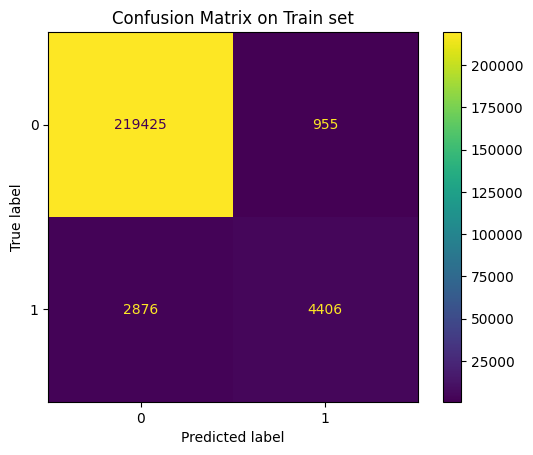

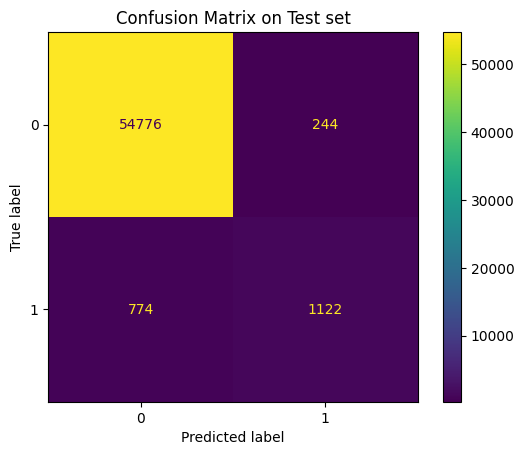

In [29]:
# Visualize confusion matrices
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    baseline, X_train, y_train, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    baseline, X_test, y_test, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

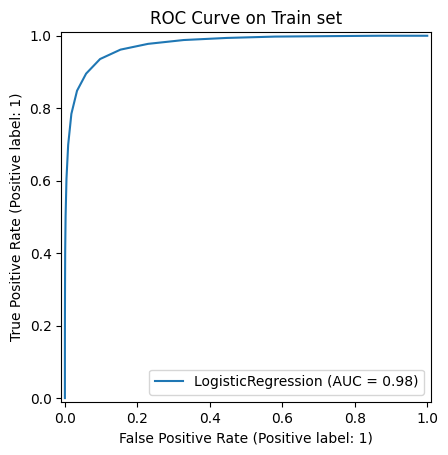

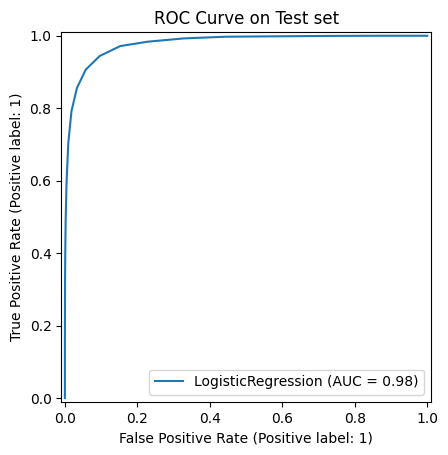

In [30]:
# Visualize ROC curves
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="ROC Curve on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(
    baseline, X_train, y_train, ax=ax
)  # RocCurveDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="ROC Curve on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(
    baseline, X_test, y_test, ax=ax
)  # RocCurveDisplay from sklearn
plt.show()

### Multivariate logistic regression

#### Separate target variable Y from features X

In [31]:
# Separate target variable Y from features X

print("Separating labels from features...")
target = 'converted'

y = df.loc[:, target]# or df.iloc[:, -1] # or  df.loc[:, df.columns == target]
X = df.drop(target, axis=1) # or df.iloc[:, 0:-1]  # All columns are kept, except the target
# or df.loc[:, df.columns != target]
print("...Done.")

print("y : ")
print(y.head())
print()
print("X : ")
print(X.head())

Separating labels from features...
...Done.
y : 
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

X : 
   country  age  new_user  source  total_pages_visited
0    china   22         1  direct                    2
1       uk   21         1     ads                    3
2  germany   20         0     seo                   14
3       us   23         1     seo                    3
4       us   28         1  direct                    3


In [32]:
# Automatically detect names of numeric/categorical columns
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Found numeric features ", numeric_features)
print("Found categorical features ", categorical_features)

Found numeric features  ['age', 'new_user', 'total_pages_visited']
Found categorical features  ['country', 'source']


#### divide dataset train set & test set 

We apply different transformations to the features, depending on their types. Numeric columns will be standardized whereas categorical columns will be one-hot-encoded. As regards missing values imputation, it can apply to every column, but different rules may be used. 

In [33]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
# WARNING : don't forget stratify=Y for classification problems
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



We don't use simple imputer because we don't have any missing values. num_imputer = SimpleImputer(strategy="median")

We normalize numeric colomns to scale them down.

#### pipelines

In [34]:
print("Preprocessing X_train...")
print(X_train.head())
print()

# categoric

cat_transformer = Pipeline(steps=[
    ('catEncoder', OneHotEncoder(drop='first'))
])
# numerical

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

Preprocessing X_train...
        country  age  new_user  source  total_pages_visited
14322        uk   37         1     ads                    3
251570       uk   27         0     seo                   13
53008        us   26         0  direct                    4
121373       us   24         0     seo                    1
151639  germany   33         0     ads                    2



In [35]:
#### pipeline global
print("Encoding categorical features and standardizing numerical features...")

preprocessor = ColumnTransformer(transformers=[
    ('cat_transformer', cat_transformer, categorical_features),
    ('num_transformer', num_transformer, numeric_features)
])

# Preprocessings on train set
print("Preprocessing sur le train set...")
X_train = preprocessor.fit_transform(X_train)
print('...Terminé.')
X_train[0:5] # MUST use this syntax because X_train is a numpy array and not a pandas DataFrame anymore
print()


Encoding categorical features and standardizing numerical features...
Preprocessing sur le train set...
...Terminé.



Nous n'utilisons pas labelEncoder sur y_test car les labels sont déjà convertis sur converted

#### Test pipeline

In [36]:
# Preprocessings sur le test train
print("Preprocessing on test set...")
X_test = preprocessor.transform(X_test) # Don't fit again !! The test set is used for validating decisions
# we made based on the training set, therefore we can only apply transformations that were parametered using the training set.
# Otherwise this creates what is called a leak from the test set which will introduce a bias in all your results.
print('...Done.')
X_test[:5, :] # MUST use this syntax because X_test is a numpy array and not a pandas DataFrame anymore

Preprocessing on test set...
...Done.


array([[ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.77869487,  0.67629326, -0.86022495],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.62497205,  0.67629326, -0.56105227],
       [ 0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        -0.79296275, -1.47864847,  3.32819262],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.41600465,  0.67629326, -0.56105227],
       [ 0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        -0.79296275,  0.67629326,  0.0372931 ]])

#### Train model

In [37]:

from sklearn.linear_model import LogisticRegression

print("Train model...")
classifier = LogisticRegression(random_state=42) # 
classifier.fit(X_train, y_train)
print("...Done.")

Train model...
...Done.


#### Predictions

In [38]:
# Predictions on training set
print("Predictions on training set...")
y_train_pred = classifier.predict(X_train)
print("...Done.")
print(y_train_pred)
print()

Predictions on training set...
...Done.
[0 1 0 ... 0 0 0]



In [39]:
# Predictions on training set
print("Predictions on training set...")
y_train_pred = classifier.predict(X_train)
print("...Done.")
print(y_train_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on training set...")
y_train_proba = classifier.predict_proba(X_train)
print("...Done.")
print(y_train_proba)
print()

Predictions on training set...
...Done.
[0 1 0 ... 0 0 0]

Probabilities on training set...
...Done.
[[9.99874953e-01 1.25046968e-04]
 [2.56557172e-01 7.43442828e-01]
 [9.97994401e-01 2.00559908e-03]
 ...
 [9.99996050e-01 3.95038360e-06]
 [9.99968964e-01 3.10364304e-05]
 [9.95939896e-01 4.06010371e-03]]



In [40]:
# Predictions on test set
print("Predictions on test set...")
y_test_pred = classifier.predict(X_test)
print("...Done.")
print(y_test_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on test set...")
y_test_proba = classifier.predict_proba(X_test)
print("...Done.")
print(y_test_proba)
print()

Predictions on test set...
...Done.
[0 0 1 ... 0 0 0]

Probabilities on test set...
...Done.
[[9.99998400e-01 1.59971099e-06]
 [9.99997458e-01 2.54178681e-06]
 [3.34890179e-02 9.66510982e-01]
 ...
 [9.95922084e-01 4.07791602e-03]
 [9.99563732e-01 4.36268287e-04]
 [9.99146349e-01 8.53651108e-04]]



#### Performance evaluation

In [41]:
# Print scores
print("accuracy on training set : ", accuracy_score(y_train, y_train_pred))
print("accuracy on test set : ", accuracy_score(y_test, y_test_pred))
print()

print("f1-score on training set : ", f1_score(y_train, y_train_pred))
print("f1-score on test set : ", f1_score(y_test, y_test_pred))
print()

accuracy on training set :  0.9862427633948573
accuracy on test set :  0.986172605242814

f1-score on training set :  0.7643695455913332
f1-score on test set :  0.7604261796042618



Attention, le jeu de données est très déséquilibré. Accuracy score n'est pas significatif. # Here, the f1-score will be used to assess the performances on the leaderboard.

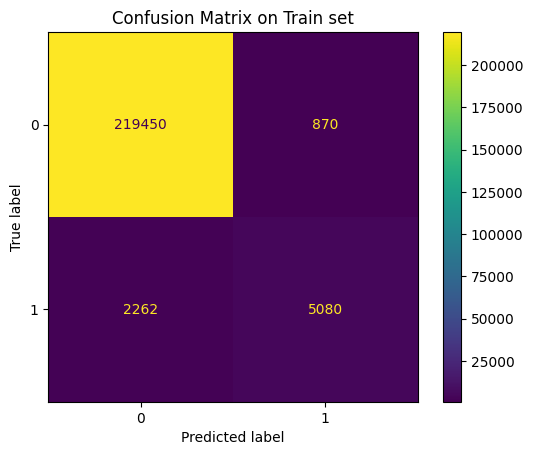

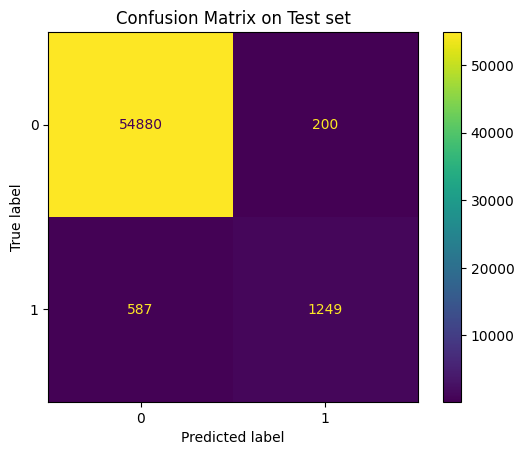

In [42]:
# Visualize confusion matrices
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    classifier, X_train, y_train, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    classifier, X_test, y_test, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

**Our baseline model reaches a f1-score of 76%.

TODO recall et précision

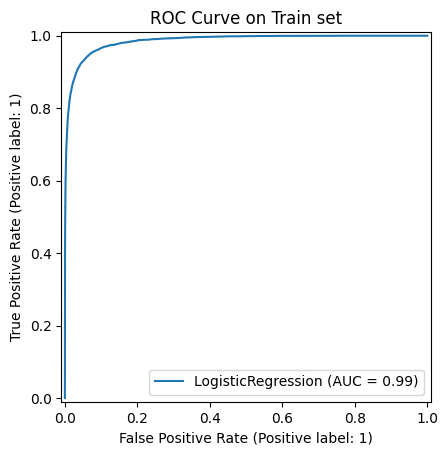

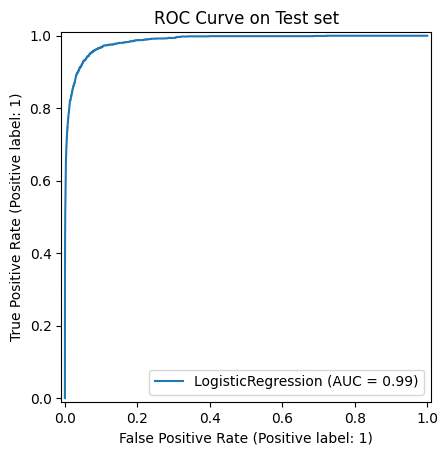

In [43]:
# Visualize ROC curves
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="ROC Curve on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(
    classifier, X_train, y_train, ax=ax
)  # RocCurveDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="ROC Curve on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
RocCurveDisplay.from_estimator(
    classifier, X_test, y_test, ax=ax
)  # RocCurveDisplay from sklearn
plt.show()


# Cross-validation

In [44]:
# Perform 10-fold cross-validation
print("5-fold cross-validation...")
scores = cross_val_score(baseline, X_train, y_train, cv=(10))
print('The cross-validated accuracy is : ', scores.mean())
print('The standard deviation is : ', scores.std())

5-fold cross-validation...
The cross-validated accuracy is :  0.9862471618095274
The standard deviation is :  0.0006673101864737961


The multivariate model is just slightly better than the baseline.

In [45]:
# Predictions on training set
print("Predictions on training set...")
y_train_pred = classifier.predict(X_train)
print("...Done.")
print(y_train_pred[:5])
print()

# Predictions on test set
print("Predictions on test set...")
y_test_pred = classifier.predict(X_test)
print("...Done.")
print(y_test_pred[:5])
print()



Predictions on training set...
...Done.
[0 1 0 0 0]

Predictions on test set...
...Done.
[0 0 1 0 0]



In [46]:
print('Coefficients of the Logistic regression model:')
classifier.coef_

Coefficients of the Logistic regression model:


array([[ 3.55676314,  3.37092221,  3.05790176, -0.22896325, -0.02517513,
        -0.6203906 , -0.80500334,  2.53734537]])

In [47]:
# Create a pandas DataFrame with the model's coefficients
X = pd.DataFrame(
    X_train,   # matrice encodée (8 colonnes)
    columns=preprocessor.get_feature_names_out()
)
coefs = pd.DataFrame(index = X.columns, data = classifier.coef_.transpose(), columns=['coef']).sort_values("coef", ascending=False)
coefs

,coef
cat_transformer__country_germany,3.556763
cat_transformer__country_uk,3.370922
cat_transformer__country_us,3.057902
num_transformer__total_pages_visited,2.537345
cat_transformer__source_seo,-0.025175
cat_transformer__source_direct,-0.228963
num_transformer__age,-0.620391
num_transformer__new_user,-0.805003


X.columns donne les 5 colonnes brutes, mais coef_ a 8 valeurs (après encodage). get_feature_names_out() donne les 8 noms dans le bon ordre.
columns=['?'] : contient les numéros de colonne. Ces informations vont me permettre d'ajuster les hyperparamètres.